In [5]:
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import get_train_test_data, train_mlp, train_baseline_model
from ml_baselines.modelling.predict import predict_baselines
from ml_baselines.config import Config
from ml_baselines.data import read_agage, read_intem

In [6]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
cfg = Config()
site = "MHD"

In [8]:
params_dict = {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 50, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000, 'solver': 'adam'}
model, X, y = train_baseline_model(site, model_type="mlp", model_params=params_dict, return_scores=False, verbose=True)

Training mlp model for site: MHD
... balancing dataset to target baseline ratio of 0.5
Number of training points: 6348
... number of baseline points: 3174 (50.0%)
... fitting
... predicting
Precision on Training Set = 0.759
Precision on Validation Set = 0.422
Precision on Test Set = 0.509
Recall on Training Set = 0.768
Recall on Validation Set = 0.780
Recall on Test Set = 0.786
F1 Score on Training Set = 0.764
F1 Score on Validation Set = 0.547
F1 Score on Test Set = 0.618


In [11]:
model, x, y = train_baseline_model("MHD", model_type="random_forest",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=10)

Training random_forest model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 0.674
Precision on Validation Set = 0.428
Precision on Test Set = 0.524
Recall on Training Set = 1.000
Recall on Validation Set = 0.744
Recall on Test Set = 0.738
F1 Score on Training Set = 0.805
F1 Score on Validation Set = 0.543
F1 Score on Test Set = 0.613


In [4]:
model, x, y = train_baseline_model("MHD", model_type="gradient_boosting",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_features":"sqrt", "subsample":0.8}, sample_weights=10)

Training gradient_boosting model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 1.000
Precision on Validation Set = 0.479
Precision on Test Set = 0.567
Recall on Training Set = 1.000
Recall on Validation Set = 0.591
Recall on Test Set = 0.555
F1 Score on Training Set = 1.000
F1 Score on Validation Set = 0.529
F1 Score on Test Set = 0.561


In [12]:
metric_dict = {}
thr_values = [0.25, 0.5, 0.75, 0.8, 0.9]
for threshold in thr_values:
    y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=threshold)
    metric_dict[threshold] = metrics

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.25
Precision: 0.338
Recall: 0.945
F1 Score: 0.498
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.5
Precision: 0.428
Recall: 0.744
F1 Score: 0.543
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.524
Recall: 0.421
F1 Score: 0.467
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.8
Precision: 0.567
Recall: 0.333
F1 Score: 0.420
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.9
Precision: 0.681
Recall: 0.081
F1 Score: 0.145


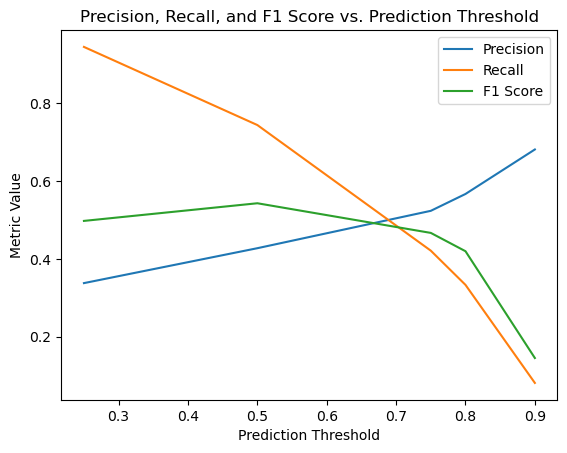

In [13]:
plt.plot(thr_values, [metric_dict[thr]["precision"] for thr in thr_values], label="Precision")
plt.plot(thr_values, [metric_dict[thr]["recall"] for thr in thr_values], label="Recall")
plt.plot(thr_values, [metric_dict[thr]["f1"] for thr in thr_values], label="F1 Score")
plt.xlabel("Prediction Threshold")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Prediction Threshold")
plt.legend()

In [35]:
weights_dict = {}
weights_list = [1,2,4,10,20]
for weight in weights_list:
    _, _, _, metrics = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=weight, return_scores=True, verbose=False, prediction_threshold=0.75)
    weights_dict[weight] = metrics

Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5


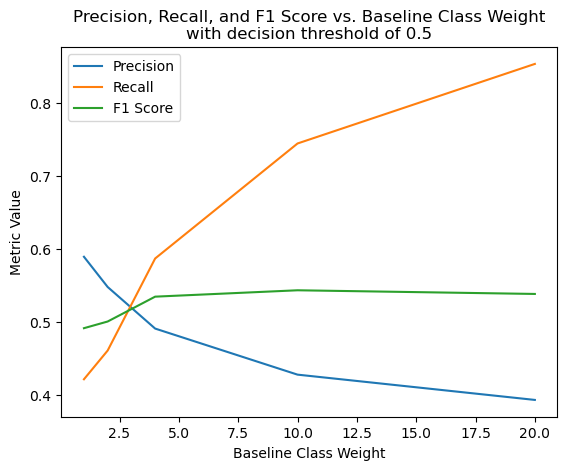

In [33]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.5")
plt.legend()

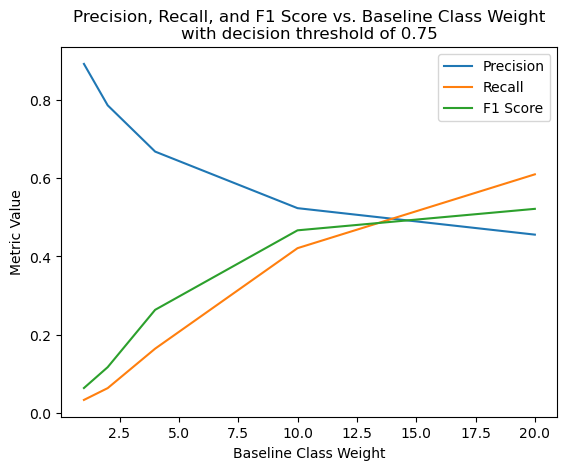

In [36]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.75")
plt.legend()

In [38]:
model, _,_  = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights="auto", return_scores=False, verbose=False)

In [39]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=0.75)

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.638
Recall: 0.185
F1 Score: 0.287


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

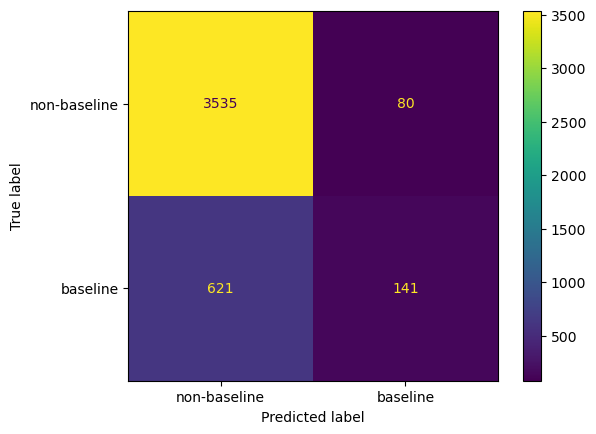

In [40]:
cm = confusion_matrix(y, y_pred, labels=model.classes_)#, normalize="all")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["non-baseline", "baseline"])
disp.plot()
plt.show()

In [18]:
site = "MHD"
species = "ch4".lower() #"hfc-134a" 
start_year=2010
end_year=2020

In [19]:
df_agage = read_agage(site, species, start_year=start_year, end_year=end_year)

In [20]:
import pandas as pd

In [41]:
# filter y by start and end year
y = y[(y.index.year >= start_year) & (y.index.year <= end_year)]
merged_df = pd.merge_asof(pd.DataFrame({"baseline": y}), df_agage["mf"], left_index=True, right_index=True, direction='nearest')
merged_df["predicted_baseline"] = y_pred

In [22]:
import numpy as np

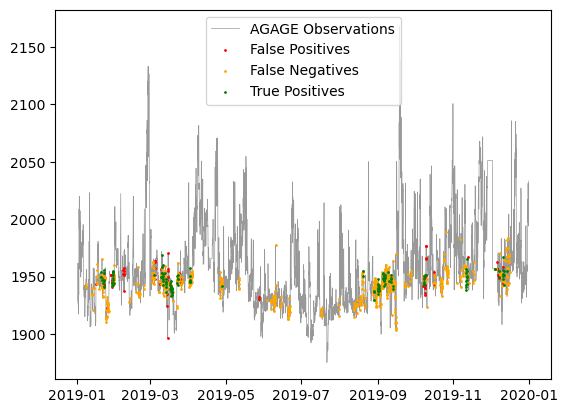

In [42]:
true_positives_mask = (merged_df.baseline == 1) & (merged_df.predicted_baseline == 1)
false_positives_mask = (merged_df.baseline == 0) & (merged_df.predicted_baseline == 1)
false_negatives_mask = (merged_df.baseline == 1) & (merged_df.predicted_baseline == 0)
plt.plot(merged_df.index, merged_df.mf, c="gray", label="AGAGE Observations", zorder=1, alpha=0.8, lw=0.5)

plt.scatter(merged_df.index[false_positives_mask], merged_df.mf[false_positives_mask], color="red", label="False Positives", zorder=5, s=1)
plt.scatter(merged_df.index[false_negatives_mask], merged_df.mf[false_negatives_mask], color="orange", label="False Negatives", zorder=5, s=1)
plt.scatter(merged_df.index[true_positives_mask], merged_df.mf[true_positives_mask], color="green", label="True Positives", zorder=5, s=1)
plt.legend()